In [7]:
import keras
import tensorflow as tf
from keras.models import Model
from keras.applications import ResNet50V2
import numpy as np
from keras.layers import Flatten,Dense,Dropout
from keras.callbacks import EarlyStopping

In [8]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train_resize=[];x_test_resize=[];input_shape=(48,48,3)
for i in x_train:
  x_train_resize.append(np.resize(i,input_shape)/255)
for i in x_test:
  x_test_resize.append(np.resize(i,input_shape)/255)
x_train_resize=np.array(x_train_resize)
x_test_resize=np.array(x_test_resize)

In [9]:
base_modal=ResNet50V2(include_top=False,classes=10,input_shape=input_shape)
base_modal.summary()


Model: "resnet50v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 48, 48, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 54, 54, 3) │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 24, 24,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 26, 26,    │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 12, 12,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 12, 12,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 12, 12,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 12, 12,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 12, 12,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 12, 12,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 14, 14,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 12, 12,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 12, 12,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 12, 12,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 12, 12,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 12, 12,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 12, 12,    │          0 │ conv2_block1_0_c

 Total params: 23,564,800 (89.89 MB)

 Trainable params: 23,519,360 (89.72 MB)

 Non-trainable params: 45,440 (177.50 KB)

In [10]:
for layers in base_modal.layers:
  if layers.name=="post_relu ":
    layers.trainable=True
    print("Layer "+layers.name+" is now trainable")
  elif layers.name==" post_bn ":
    layers.trainable=True
    print("Layer "+layers.name+" is now trainable")
  elif layers.name=="conv5_block3_out":
    layers.trainable=True
    print("Layer "+layers.name+" is now trainable")
  elif layers.name=="conv5_block3_3_conv":
    layers.trainable=True
    print("Layer "+layers.name+" is now trainable")
  elif layers.name=="conv5_block3_3_bn":
    layers.trainable=True
    print("Layer "+layers.name+" is now trainable")
  elif layers.name=="conv5_block3_2_relu":
    layers.trainable=True
    print("Layer "+layers.name+" is now trainable")
  elif layers.name=="conv5_block3_2_conv":
    layers.trainable=True
    print("Layer "+layers.name+" is now trainable")
  elif layers.name=="conv5_block3_2_bn":
    layers.trainable=True
    print("Layer "+layers.name+" is now trainable")
  elif layers.name=="conv5_block3_1_relu":
    layers.trainable=True
    print("Layer "+layers.name+" is now trainable")
  elif layers.name=="conv5_block3_1_conv":
    layers.trainable=True
    print("Layer "+layers.name+" is now trainable")
  elif layers.name=="conv5_block3_1_bn":
    layers.trainable=True
    print("Layer "+layers.name+" is now trainable")
  else:
    layers.trainable=False
    print("Layer "+layers.name+" is now non-trainable")


Layer input_layer_1 is now non-trainable
Layer conv1_pad is now non-trainable
Layer conv1_conv is now non-trainable
Layer pool1_pad is now non-trainable
Layer pool1_pool is now non-trainable
Layer conv2_block1_preact_bn is now non-trainable
Layer conv2_block1_preact_relu is now non-trainable
Layer conv2_block1_1_conv is now non-trainable
Layer conv2_block1_1_bn is now non-trainable
Layer conv2_block1_1_relu is now non-trainable
Layer conv2_block1_2_pad is now non-trainable
Layer conv2_block1_2_conv is now non-trainable
Layer conv2_block1_2_bn is now non-trainable
Layer conv2_block1_2_relu is now non-trainable
Layer conv2_block1_0_conv is now non-trainable
Layer conv2_block1_3_conv is now non-trainable
Layer conv2_block1_out is now non-trainable
Layer conv2_block2_preact_bn is now non-trainable
Layer conv2_block2_preact_relu is now non-trainable
Layer conv2_block2_1_conv is now non-trainable
Layer conv2_block2_1_bn is now non-trainable
Layer conv2_block2_1_relu is now non-trainable
Laye

In [11]:
last=base_modal.layers[-1].output
x=Dropout(0.3)(last)
x=Flatten()(x)
x=Dropout(0.3)(x)
x=Dense(10,activation='softmax',name='classification')(x)
model=Model(base_modal.input,x)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 48, 48, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 54, 54, 3) │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 24, 24,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 26, 26,    │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 12, 12,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 12, 12,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 12, 12,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 12, 12,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 12, 12,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 12, 12,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 14, 14,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 12, 12,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 12, 12,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 12, 12,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 12, 12,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 12, 12,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 12, 12,    │          0 │ conv2_block1_0_c

 Total params: 23,646,730 (90.21 MB)

 Trainable params: 4,542,474 (17.33 MB)

 Non-trainable params: 19,104,256 (72.88 MB)

In [12]:
optimizer=keras.optimizers.Adam(learning_rate=0.05)
model.compile(optimizer=optimizer,loss='sparse_categorical_crossentropy',metrics=['accuracy'])
es=EarlyStopping(monitor='loss',mode='min',verbose=1,patience=20)
hist=model.fit(x_train_resize,y_train,epochs=150,batch_size=32,validation_split=0.2,callbacks=[es])

Epoch 1/150
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 21ms/step - accuracy: 0.1031 - loss: 62.2445 - val_accuracy: 0.1026 - val_loss: 2.3148
Epoch 2/150
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.1011 - loss: 2.3341 - val_accuracy: 0.0950 - val_loss: 2.3133
Epoch 3/150
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.0999 - loss: 2.3156 - val_accuracy: 0.1014 - val_loss: 2.3047
Epoch 4/150
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.1024 - loss: 2.4264 - val_accuracy: 0.0950 - val_loss: 2.3184
Epoch 5/150
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.1016 - loss: 2.3123 - val_accuracy: 0.1014 - val_loss: 2.3086
Epoch 6/150
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.0948 - loss: 2.3092 - val_accuracy: 0.0980 - val_loss: 2.3083
Epoch 7/150
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.1019 - loss: 2.3086 - val_accuracy: 0.0977 - val_loss: 2.3074
Epoch 8/150
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy:

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━

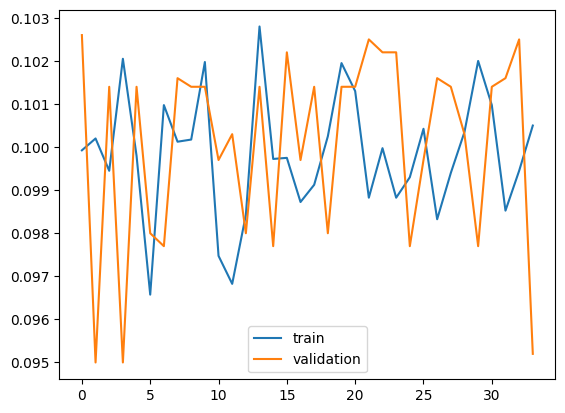

In [16]:
import matplotlib.pyplot as plt

# Create a TensorFlow Dataset for batching
test_dataset = tf.data.Dataset.from_tensor_slices(x_test_resize).batch(32) # Use the same batch size as training

# Predict in batches
y_pred = []
for batch in test_dataset:
    y_pred.extend(model.predict(batch))

y_pred = np.array(y_pred)

plt.plot(hist.history['accuracy'],label="train")
plt.plot(hist.history['val_accuracy'],label='validation')
plt.legend()